# DSH interactive playground

Set the physical parameters in the **Parameters** cell, run all cells, and the DSH image is displayed inline at the bottom. This notebook mirrors `scripts/run_dsh_v1.py` / `dsh/cli.py` but keeps everything in memory instead of writing FITS/NPZ files.

Requires `matplotlib` and a Jupyter kernel in addition to the project's normal dependencies:

```bash
python -m pip install -e ".[dev]" matplotlib jupyter
```

In [ ]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"  # avoid the crash-prone experimental Metal/GPU backend

import numpy as np
import matplotlib.pyplot as plt
from jax import random

from dsh.examples import (
    DAY_S, 
    build_synthetic_four_cloud_scene,
    build_v1_decay_source,
    build_v1_test_source,
)
from dsh.geometry.clouds import centers_to_edges, cloud_from_loaded_fits
from dsh.observer.binning import build_observer_bin_geometry
from dsh.physics.absorption import load_photoelectric_absorption_table
from dsh.physics.newdust import (
    build_dust_physics_from_tables,
    load_newdust_scattering_table,
)
from dsh.pipeline import (
    TRANSPORT_STATUS_LABELS,
    run_tabulated_source_to_observer_chunked,
)
from dsh.sources.launch import build_cloud_launch_geometry

## Parameters — edit these

`SOURCE_MODEL` is either `"constant-flare"` (a one-hour flare) or `"exponential-decay"` (a post-outburst decay; uses the `DECAY_*` / `BASELINE_BAND_FLUXES` fields below).

Set `CLOUD_FITS_PATH` to a `pathlib.Path` to use a physical `delta_NH` FITS cube instead of the built-in synthetic four-cloud scene.

In [7]:
# --- geometry ---
SOURCE_DISTANCE_KPC = 10.0
CLOUD_FITS_PATH = None  # e.g. Path("/path/to/delta_nh_cube.fits")

# --- source model ---
# Isolated to the 4.9 keV band only (bands zeroed at 3.3 and 6.9 keV),
# to match the mono-energetic RefleX comparison run
# (reflex_comparison/disc_comparison.par with %ENERGY=4900).
SOURCE_MODEL = "constant-flare"  # "constant-flare" or "exponential-decay"
PEAK_BAND_FLUXES = (0.0, 1.2e-2, 0.0)  # ph cm^-2 s^-1 at 3.3/4.9/6.9 keV
BASELINE_BAND_FLUXES = (0.0, 0.0, 0.0)  # exponential-decay only
DECAY_TIME_DAYS = 25.0
DECAY_START_DAYS = 0.0
DECAY_DURATION_DAYS = 120.0
SOURCE_TIME_BIN_DAYS = 0.25

# --- Monte Carlo run ---
# Increased from 100_000 -- the earlier run only produced 35 scattering
# interactions, too sparse for a clean comparison image.
PACKETS = 2_000_000
CHUNK_SIZE = 65_536
MAX_INTERACTIONS = 8
SEED = 2026

# --- observer binning ---
ARRIVAL_DAYS = 60.0
TIME_BIN_DAYS = 1.0

## Build physics tables, cloud, and source

In [8]:
scattering = load_newdust_scattering_table()
absorption = load_photoelectric_absorption_table()
physics = build_dust_physics_from_tables(scattering, absorption)

""" if CLOUD_FITS_PATH is None:
    cloud = build_synthetic_four_cloud_scene(SOURCE_DISTANCE_KPC)
    cloud_description = "built-in four-cloud synthetic scene" """
if CLOUD_FITS_PATH is None:
    import numpy as np
    from dsh.geometry.clouds import build_angular_distance_cloud
    from dsh.geometry.clouds import centers_to_edges, KPC_TO_CM

    # grid — same idea as build_synthetic_four_cloud_scene
    x_arcsec = np.arange(-150.0, 155.0, 5.0)
    y_arcsec = np.arange(-150.0, 155.0, 5.0)
    z_kpc = np.arange(1.0, 9.0, 0.05)

    sky_x, sky_y = np.meshgrid(x_arcsec, y_arcsec, indexing="xy")

    # disc parameters
    center_x_arcsec, center_y_arcsec = 0.0, 0.0     # sky-plane center
    center_z_kpc = 5.0                               # distance from observer
    disc_radius_arcsec = 80.0                        # in-plane radius
    disc_thickness_kpc = 0.3                         # thickness along the line of sight
    N_H_CM3 = 10.0                                    # fixed hydrogen density inside the disc [cm^-3]

    r = np.sqrt((sky_x - center_x_arcsec) ** 2 + (sky_y - center_y_arcsec) ** 2)

    z_edges_kpc = centers_to_edges(z_kpc)
    radial_bin_width_cm = np.diff(z_edges_kpc) * KPC_TO_CM   # shape (n_z,)

    inside_disc = (
        (r[None, :, :] <= disc_radius_arcsec)
        & (np.abs(z_kpc[:, None, None] - center_z_kpc) <= 0.5 * disc_thickness_kpc)
    )

    n_h_grid = np.where(inside_disc, N_H_CM3, 0.0)                     # shape (n_z, n_y, n_x)
    delta_nh = n_h_grid * radial_bin_width_cm[:, None, None]           # convert to column increments

    cloud = build_angular_distance_cloud(
        delta_nh,
        x_centers_arcsec=x_arcsec,
        y_centers_arcsec=y_arcsec,
        z_centers_kpc=z_kpc,
        source_distance_kpc=SOURCE_DISTANCE_KPC,
    )
    cloud_description = "custom uniform-density disc cloud"
else:
    from dsh.io.cloud_fits import load_cube


    cloud = cloud_from_loaded_fits(
        load_cube(CLOUD_FITS_PATH),
        source_distance_kpc=SOURCE_DISTANCE_KPC,
    )
    cloud_description = str(CLOUD_FITS_PATH)

if SOURCE_MODEL == "constant-flare":
    source = build_v1_test_source(scattering.energy_kev, band_flux=PEAK_BAND_FLUXES)
elif SOURCE_MODEL == "exponential-decay":
    source = build_v1_decay_source(
        scattering.energy_kev,
        peak_band_flux=PEAK_BAND_FLUXES,
        baseline_band_flux=BASELINE_BAND_FLUXES,
        decay_time_days=DECAY_TIME_DAYS,
        decay_start_days=DECAY_START_DAYS,
        decay_duration_days=DECAY_DURATION_DAYS,
        source_time_bin_days=SOURCE_TIME_BIN_DAYS,
    )
else:
    raise ValueError("SOURCE_MODEL must be 'constant-flare' or 'exponential-decay'")

print(f"Cloud: {cloud_description}")
print(f"Cloud shape (z, y, x): {tuple(cloud.delta_nh_cm2.shape)}")
print(f"Simulated source fluence: {float(np.asarray(source.total_fluence)):.7g} ph cm^-2")

Cloud: custom uniform-density disc cloud
Cloud shape (z, y, x): (160, 61, 61)
Simulated source fluence: 43.2 ph cm^-2


In [9]:
def build_arrival_edges_s(arrival_days, time_bin_days):
    n_bins = int(np.ceil(arrival_days / time_bin_days))
    return np.linspace(0.0, arrival_days * DAY_S, n_bins + 1)


arrival_edges_s = build_arrival_edges_s(ARRIVAL_DAYS, TIME_BIN_DAYS)
if float(np.asarray(source.time_edges_s)[-1]) >= arrival_edges_s[-1]:
    raise ValueError(
        "ARRIVAL_DAYS must extend beyond the final source-emission time "
        "to leave room for dust-scattering delays"
    )

launch_geometry = build_cloud_launch_geometry(cloud)
bin_geometry = build_observer_bin_geometry(
    sky_x_edges_arcsec=np.asarray(cloud.x_edges_arcsec),
    sky_y_edges_arcsec=np.asarray(cloud.y_edges_arcsec),
    energy_edges_kev=centers_to_edges(scattering.energy_kev),
    arrival_time_edges_s=arrival_edges_s,
)

## Run the simulation

In [ ]:
def report_progress(completed, total):
    print(f"\rCompleted packets: {completed:,} / {total:,}", end="" if completed < total else "\n")


result = run_tabulated_source_to_observer_chunked(
    random.PRNGKey(SEED),
    source,
    launch_geometry,
    cloud,
    physics,
    bin_geometry,
    total_packets=PACKETS,
    chunk_size=CHUNK_SIZE,
    max_interactions=MAX_INTERACTIONS,
    progress_callback=report_progress,
)

Completed packets: 655,360 / 2,000,000

## Diagnostics

In [9]:
status_count = np.asarray(result.diagnostics.transport_status_count)
print("Transport terminal states:")
for label, count in zip(TRANSPORT_STATUS_LABELS, status_count, strict=True):
    print(f"  {label}: {int(count):,}")
print(
    "Analog interactions/scatterings: "
    f"{int(result.diagnostics.analog_interaction_count):,} / "
    f"{int(result.diagnostics.analog_scattering_count):,}"
)
print(
    "Scored/binned observer fluence [ph cm^-2]: "
    f"{float(result.diagnostics.scored_observer_fluence):.7g} / "
    f"{float(result.products.binned_weight_observer_fluence):.7g}"
)

Transport terminal states:
  active: 0
  reached the observer plane: 99,988
  escaped through the outer transport boundary: 0
  absorbed: 12
  reached the numerical interaction safety limit: 0
  energy lies outside the dust table: 0
  position or photon four-momentum is invalid: 0
Analog interactions/scatterings: 29 / 17
Scored/binned observer fluence [ph cm^-2]: 1.748252 / 1.748252


## DSH image (integrated over arrival time and energy)

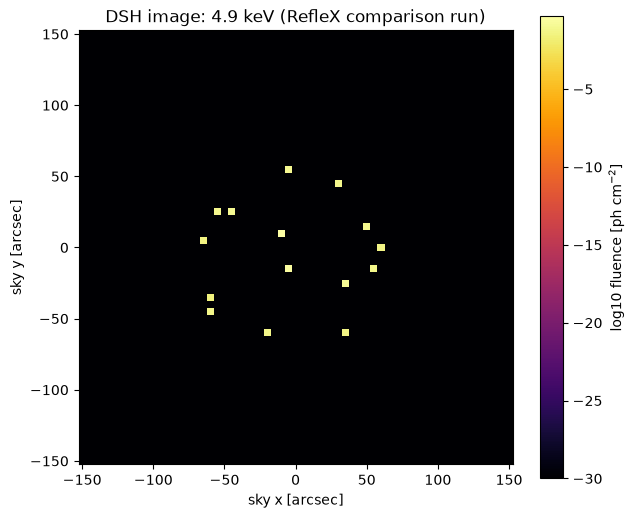

In [10]:
total_fluence = np.asarray(result.products.total_fluence)  # (n_time, n_energy, n_y, n_x)

# Only the 4.9 keV band (index 1) has nonzero flux in this run -- select
# it explicitly rather than summing over energy, so this is directly
# comparable to the RefleX mono-energetic run (halo_e4p9.fits).
energy_kev_all = np.asarray(scattering.energy_kev)
energy_index_4p9 = int(np.argmin(np.abs(energy_kev_all - 4.9)))
image = total_fluence[:, energy_index_4p9, :, :].sum(axis=0)

x_edges = np.asarray(bin_geometry.sky_x_edges_arcsec)
y_edges = np.asarray(bin_geometry.sky_y_edges_arcsec)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(
    np.log10(image + 1e-30),
    origin="lower",
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    cmap="inferno",
    aspect="equal",
)
ax.set_xlabel("sky x [arcsec]")
ax.set_ylabel("sky y [arcsec]")
ax.set_title(f"DSH image: {energy_kev_all[energy_index_4p9]:.1f} keV (RefleX comparison run)")
fig.colorbar(im, ax=ax, label="log10 fluence [ph cm$^{-2}$]")
plt.show()

## DSH image cropped to the RefleX camera's field of view

Crops the same ideal-observer image to the field of view used by the RefleX
`IMAGE NEW` command in `reflex_comparison/disc_comparison.par`, for a direct
side-by-side comparison. No PSF/blur is applied — this stays DSH's zero-
aperture, infinite-resolution product (per the README, instrument response
is intentionally deferred); the RefleX aperture's implied angular resolution
is only printed for reference, not applied to the image.

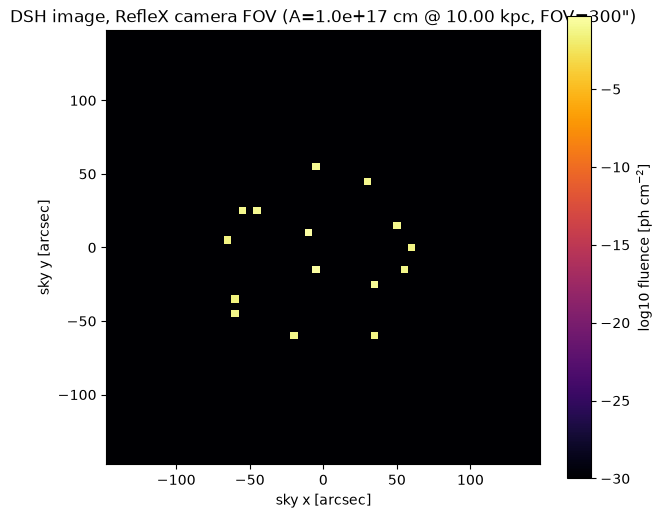

RefleX-equivalent aperture resolution (not applied): 0.668 arcsec


In [11]:
# --- camera parameters, matched to reflex_comparison/disc_comparison.par's
# IMAGE NEW command: "IMAGE NEW halo_e4p9.fits 0.0 0.0 3.085678e22 1.0e17 0.08333 61" ---
APERTURE_CM = 1.0e17               # collecting aperture radius (RefleX's `A`)
APERTURE_DISTANCE_KPC = SOURCE_DISTANCE_KPC  # camera distance from the source (RefleX's Z, 10 kpc)
FOV_ARCSEC = 300.0                 # field-of-view width (RefleX's F=0.08333 deg = 300")

KPC_TO_CM = 3.0856775814913673e21
ARCSEC_TO_RAD = np.pi / (180.0 * 3600.0)

# No PSF/blur applied -- this is the same ideal-observer image, just cropped
# to the RefleX camera's field of view. The aperture-implied resolution is
# printed below for reference only (RefleX's own A/D formula).
psf_resolution_rad = APERTURE_CM / (APERTURE_DISTANCE_KPC * KPC_TO_CM)
psf_resolution_arcsec = psf_resolution_rad / ARCSEC_TO_RAD

# crop to the requested field of view, centered on (0, 0)
x_lo = np.searchsorted(x_edges, -FOV_ARCSEC / 2, side="left")
x_hi = np.searchsorted(x_edges, FOV_ARCSEC / 2, side="right") - 1
y_lo = np.searchsorted(y_edges, -FOV_ARCSEC / 2, side="left")
y_hi = np.searchsorted(y_edges, FOV_ARCSEC / 2, side="right") - 1

cropped_x_edges = x_edges[x_lo:x_hi + 1]
cropped_y_edges = y_edges[y_lo:y_hi + 1]
cropped_image = image[y_lo:y_hi, x_lo:x_hi]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(
    np.log10(cropped_image + 1e-30),
    origin="lower",
    extent=[cropped_x_edges[0], cropped_x_edges[-1], cropped_y_edges[0], cropped_y_edges[-1]],
    cmap="inferno",
    aspect="equal",
)
ax.set_xlabel("sky x [arcsec]")
ax.set_ylabel("sky y [arcsec]")
ax.set_title(
    f"DSH image, RefleX camera FOV (A={APERTURE_CM:.1e} cm @ "
    f"{APERTURE_DISTANCE_KPC:.2f} kpc, FOV={FOV_ARCSEC:.0f}\")"
)
fig.colorbar(im, ax=ax, label="log10 fluence [ph cm$^{-2}$]")
plt.show()

print(f"RefleX-equivalent aperture resolution (not applied): {psf_resolution_arcsec:.3f} arcsec")

## Optional: light curve and per-energy images

In [ ]:
time_centers_days = 0.5 * (arrival_edges_s[:-1] + arrival_edges_s[1:]) / DAY_S
lightcurve = total_fluence.sum(axis=(1, 2, 3))

plt.figure(figsize=(7, 4))
plt.plot(time_centers_days, lightcurve, marker="o", markersize=3)
plt.xlabel("arrival time [days]")
plt.ylabel("fluence per time bin [ph cm$^{-2}$]")
plt.yscale("log")
plt.title("DSH halo light curve (echo of the source light curve)")
plt.show()

In [ ]:
energy_kev = np.asarray(scattering.energy_kev)
n_energy = energy_kev.size

fig, axes = plt.subplots(1, n_energy, figsize=(5 * n_energy, 5))
axes = np.atleast_1d(axes)
im = None
for index, ax in enumerate(axes):
    energy_image = total_fluence[:, index, :, :].sum(axis=0)
    im = ax.imshow(
        np.log10(energy_image + 1e-30),
        origin="lower",
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
        cmap="inferno",
    )
    ax.set_title(f"{energy_kev[index]:.1f} keV")
    ax.set_xlabel("sky x [arcsec]")
axes[0].set_ylabel("sky y [arcsec]")
fig.colorbar(im, ax=axes.tolist(), label="log10 fluence [ph cm$^{-2}$]", shrink=0.8)
plt.show()

## Optional: save this run to disk

In [ ]:
SAVE_OUTPUT = False

if SAVE_OUTPUT:
    from pathlib import Path

    from dsh.io.fits_output import write_ideal_observer_fits
    from dsh.io.npz_output import write_ideal_observer_npz

    output_path = Path("outputs/notebook_run.npz")
    fits_path = output_path.with_suffix(".fits")
    run_metadata = {
        "packets": PACKETS,
        "chunk_size": CHUNK_SIZE,
        "max_interactions": MAX_INTERACTIONS,
        "seed": SEED,
        "cloud_description": cloud_description,
        "source_model": SOURCE_MODEL,
        "peak_band_fluxes": PEAK_BAND_FLUXES,
        "baseline_band_fluxes": BASELINE_BAND_FLUXES,
        "decay_time_days": DECAY_TIME_DAYS if SOURCE_MODEL == "exponential-decay" else None,
        "decay_start_days": DECAY_START_DAYS if SOURCE_MODEL == "exponential-decay" else None,
        "decay_duration_days": DECAY_DURATION_DAYS if SOURCE_MODEL == "exponential-decay" else None,
        "source_time_bin_days": SOURCE_TIME_BIN_DAYS if SOURCE_MODEL == "exponential-decay" else None,
    }
    write_ideal_observer_npz(
        output_path, result, bin_geometry, source, cloud, physics, launch_geometry,
        run_metadata=run_metadata,
    )
    write_ideal_observer_fits(
        fits_path, result, bin_geometry, source, cloud, physics, launch_geometry,
        run_metadata=run_metadata,
    )
    print(f"Saved {output_path} and {fits_path}")